In [1]:
import numpy as np
import scipy.linalg

## Instrumental variable regression

In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import linearmodels.iv.model as lm

In [3]:
houseprices = sm.datasets.get_rdataset(
    dataname="HousePrices", package="AER", cache=True
).data
print(houseprices.iloc[:, list(range(3)) + [5] + [10]].head())

   price  lotsize  bedrooms driveway  garage
0  42000     5850         3      yes       1
1  38500     4000         2      yes       0
2  49500     3060         3      yes       0
3  60500     6650         3      yes       0
4  61000     6360         2      yes       0


In [4]:
mlr1 = smf.ols(formula="price ~ lotsize + bedrooms", data=houseprices).fit()

In [6]:
print(mlr1.summary().tables[1])
print(mlr1.fvalue, mlr1.f_pvalue)

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5612.5997   4102.819      1.368      0.172   -2446.741    1.37e+04
lotsize        6.0530      0.424     14.265      0.000       5.219       6.887
bedrooms    1.057e+04   1247.676      8.470      0.000    8116.488     1.3e+04
159.63670493607705 2.9548667338156808e-55


In [5]:
mdatac = sm.add_constant(data=houseprices, prepend=False)
mlr2 = lm.IV2SLS(
    dependent=mdatac["price"],
    exog=mdatac[["const", "bedrooms"]],
    endog=mdatac["lotsize"],
    instruments=mdatac[["driveway", "garage"]],
).fit(cov_type="homoskedastic", debiased=True)

In [7]:
print(mlr2.summary.tables[1])
print(mlr2.f_statistic)

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const      -1.913e+04     6540.7    -2.9248     0.0036  -3.198e+04     -6282.0
bedrooms       7680.1     1574.1     4.8791     0.0000      4588.1   1.077e+04
lotsize        12.519     1.2400     10.096     0.0000      10.084      14.955
Model F-statistic
H0: All parameters ex. constant are zero
Statistic: 91.5197
P-value: 0.0000
Distributed: F(2,543)


# Missing data imputation figures

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
ERROR_0 = 0.31
ERROR_100 = 0.04
MICVAE_ERR = 0.12
ORACLE_ERR = 0.1
PATTERN_SDEV = 0.2
POOLED_ERR = 0.16
BERNOULLI_ERR = 0.19
MASKED_ERR = 0.15
ELBO_ERR = 0.17
DAE_ERR = 0.21

result_dict = {"Oracle": 0.1, "MICVAE": 0.12, "Pooled": 0.16, "Bernoulli": 0.19}
ablation_dict = {"MICVAE": 0.12, "Masked": 0.16, "No Group": 0.19, "DAE": 0.21}
ablation_dict = {"MICVAE": 0.12, "DAE": 0.21}
# err_dict = {'oracle': 0.12}

NUM_SAMPLES = 30
NUM_PATTERNS = 7
EXPONENT = 2
SCALE = 500

color_list = sns.color_palette("Set2")
color_dict = {
    "Oracle": color_list[0],
    "MICVAE": color_list[1],
    "Pooled": color_list[2],
    "Bernoulli": color_list[3],
    "DAE": color_list[4],
    "Masked": color_list[5],
    "No Group": color_list[6],
}

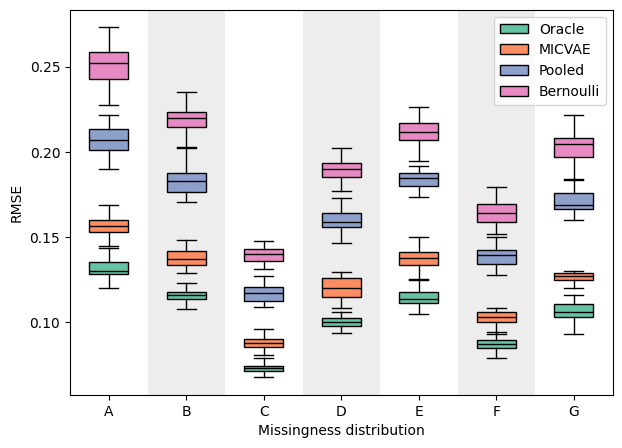

In [5]:
np.random.seed(10)

plt.figure(figsize=(7, 5))

pattern_lags = np.random.normal(0, 0.2, size=(7))

for model_idx, model_key in enumerate(result_dict.keys()):
    score_set = []
    for idx in range(NUM_PATTERNS):
        x = np.exp(pattern_lags[idx]) * result_dict[model_key]
        scores = np.random.gamma(x * (x/SCALE)**(-1), scale=(x/SCALE)**1, size=(NUM_SAMPLES))
        score_set.append(scores)
    boxplots = plt.boxplot(
        score_set,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black"),
        label=model_key,
    )
    for patch in boxplots['boxes']:
        patch.set_facecolor(color_dict[model_key])

# plt.ylim(0.05, 0.3)
for idx in range(1, 1+NUM_PATTERNS):
    if idx % 2 == 0:
        plt.axvspan(idx-0.5, idx+0.5, facecolor="lightgray", alpha=0.4)

plt.xlabel("Missingness distribution")
plt.ylabel("RMSE")
plt.xticks(np.arange(NUM_PATTERNS)+1, ['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.legend()
plt.savefig(fname='micvae_result.pdf')
plt.show()

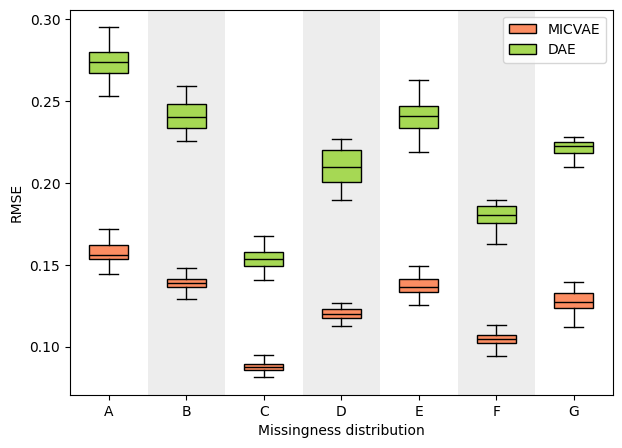

In [8]:
np.random.seed(10)

plt.figure(figsize=(7, 5))

pattern_lags = np.random.normal(0, 0.2, size=(7))

for model_idx, model_key in enumerate(ablation_dict.keys()):
    score_set = []
    for idx in range(NUM_PATTERNS):
        x = np.exp(pattern_lags[idx]) * ablation_dict[model_key]
        scores = np.random.gamma(
            x * (x / SCALE) ** (-1), scale=(x / SCALE) ** 1, size=(NUM_SAMPLES)
        )
        score_set.append(scores)
    boxplots = plt.boxplot(
        score_set,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black"),
        label=model_key,
    )
    for patch in boxplots["boxes"]:
        patch.set_facecolor(color_dict[model_key])

# plt.ylim(0.05, 0.3)
for idx in range(1, 1 + NUM_PATTERNS):
    if idx % 2 == 0:
        plt.axvspan(idx - 0.5, idx + 0.5, facecolor="lightgray", alpha=0.4)

plt.xlabel("Missingness distribution")
plt.ylabel("RMSE")
plt.xticks(np.arange(NUM_PATTERNS) + 1, ["A", "B", "C", "D", "E", "F", "G"])
plt.legend()
plt.savefig(fname="ablation_result.pdf")
plt.show()

# Unsupervised domain adaptation figures

## Causal mechanism for diabetes risk

In [47]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

In [48]:
np.random.seed(10)
color_list = sns.color_palette("Set2")

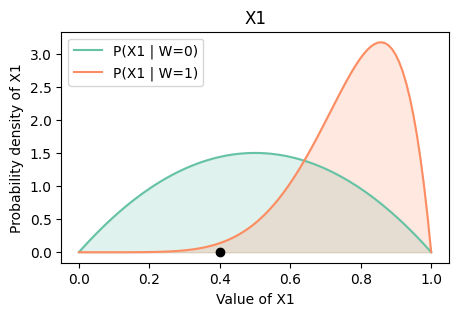

In [93]:
plt.figure(figsize=(5, 3))

# plt.axhline(0, c="black")
vals = np.linspace(0, 1, 100)
px1_0 = stats.beta.pdf(vals, 2, 2)
px1_1 = stats.beta.pdf(vals, 7, 2)
plt.fill_between(vals, 0, px1_0, color=color_list[0], alpha=0.2)
plt.plot(vals, px1_0, color=color_list[0], label="P(X1 | W=0)")
plt.fill_between(vals, 0, px1_1, color=color_list[1], alpha=0.2)
plt.plot(vals, px1_1, color=color_list[1], label="P(X1 | W=1)")
plt.scatter([0.4], [0], c="black")

plt.legend()
plt.ylabel("Probability density of X1")
plt.xlabel("Value of X1")
plt.title("X1")
plt.savefig(fname="X1.svg", bbox_inches="tight")
plt.show()

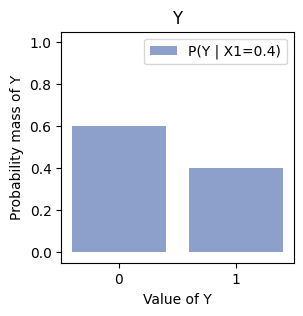

In [97]:
plt.figure(figsize=(3, 3))

vals = np.array([0, 1])
py = [0.6, 0.4]
plt.bar(vals, py, color=color_list[2], width=0.8, label="P(Y | X1=0.4)")

plt.legend()
plt.xticks(vals)
plt.ylim(-0.05, 1.05)
plt.ylabel("Probability mass of Y")
plt.xlabel("Value of Y")
plt.title("Y")
plt.savefig(fname="Y.svg", bbox_inches="tight")
plt.show()

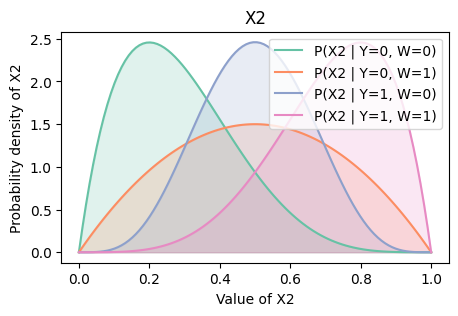

In [92]:
plt.figure(figsize=(5, 3))

vals = np.linspace(0, 1, 100)
px2_0 = stats.beta.pdf(vals, 2, 5)
px2_1 = stats.beta.pdf(vals, 2, 2)
px2_2 = stats.beta.pdf(vals, 5, 5)
px2_3 = stats.beta.pdf(vals, 5, 2)

# plt.axhline(0, c="black")
plt.fill_between(vals, 0, px2_0, color=color_list[0], alpha=0.2)
plt.plot(vals, px2_0, color=color_list[0], label="P(X2 | Y=0, W=0)")
plt.fill_between(vals, 0, px2_1, color=color_list[1], alpha=0.2)
plt.plot(vals, px2_1, color=color_list[1], label="P(X2 | Y=0, W=1)")
plt.fill_between(vals, 0, px2_2, color=color_list[2], alpha=0.2)
plt.plot(vals, px2_2, color=color_list[2], label="P(X2 | Y=1, W=0)")
plt.fill_between(vals, 0, px2_3, color=color_list[3], alpha=0.2)
plt.plot(vals, px2_3, color=color_list[3], label="P(X2 | Y=1, W=1)")

plt.legend()
plt.ylabel("Probability density of X2")
plt.xlabel("Value of X2")
plt.title("X2")
plt.savefig(fname="X2.svg", bbox_inches="tight")
plt.show()

## X1 is a reliable predictor, X2 is not

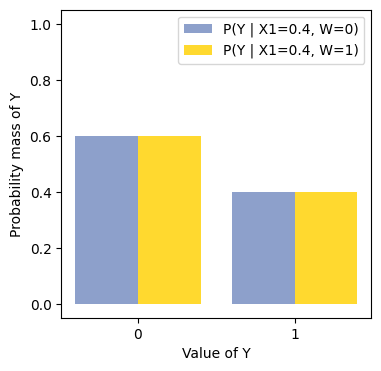

In [83]:
plt.figure(figsize=(4, 4))

x1 = 0.4
w_1 = 0
w_2 = 1

vals = np.array([0, 1])
py_1 = [1-x1, x1]
py_2 = [1-x1, x1]

plt.bar(
    vals - 0.2,
    py_1,
    color=color_list[2],
    width=0.4,
    label=f"P(Y | X1={x1}, W={w_1})",
)
plt.bar(
    vals + 0.2,
    py_2,
    color=color_list[5],
    width=0.4,
    label=f"P(Y | X1={x1}, W={w_2})",
)

plt.legend()
plt.xticks(vals)
plt.ylim(-0.05, 1.05)
plt.ylabel("Probability mass of Y")
plt.xlabel("Value of Y")
plt.savefig(fname="X1_shift.pdf", bbox_inches="tight")
plt.show()

In [72]:
num_samples = 100000
threshold = 0.01

w_1 = 0
w_2 = 1
x2 = 0.4


def sampling():
    p = np.random.uniform()
    y = stats.binom.rvs(n=1, p=p, size=1)[0]
    x2_1 = stats.beta.rvs(a=2 + 3 * y, b=5 - 3 * w_1, size=1)[0]
    x2_2 = stats.beta.rvs(a=2 + 3 * y, b=5 - 3 * w_2, size=1)[0]
    return [y, x2_1, x2_2]


samples = np.array(Parallel(n_jobs=4)(delayed(sampling)() for _ in range(num_samples)))

y = samples[:, 0]
x2_1 = samples[:, 1]
x2_2 = samples[:, 2]

idcs_1 = np.less(np.abs(x2 - x2_1), threshold)
idcs_2 = np.less(np.abs(x2 - x2_2), threshold)

py_1 = np.mean(y[idcs_1])
py_2 = np.mean(y[idcs_2])

py_1 = [1 - py_1, py_1]
py_2 = [1 - py_2, py_2]

print(py_1, py_2)

[0.41038118410381186, 0.5896188158961881] [0.7551975051975052, 0.2448024948024948]


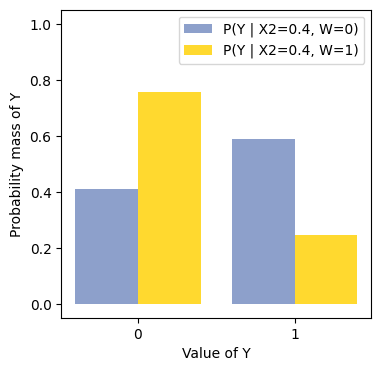

In [81]:
plt.figure(figsize=(4, 4))

vals = np.array([0, 1])
plt.bar(
    vals - 0.2,
    py_1,
    color=color_list[2],
    width=0.4,
    label=f"P(Y | X2={x2}, W={w_1})",
)
plt.bar(
    vals + 0.2,
    py_2,
    color=color_list[5],
    width=0.4,
    label=f"P(Y | X2={x2}, W={w_2})",
)

plt.legend()
plt.xticks(vals)
plt.ylim(-0.05, 1.05)
plt.ylabel("Probability mass of Y")
plt.xlabel("Value of Y")
plt.savefig(fname="X2_shift.pdf", bbox_inches="tight")
plt.show()

## X2 is still a good predictor when W is constant

In [56]:
num_samples = 100000
threshold = 0.01

x1 = 0.4
x2_1 = 0.3
x2_2 = 0.8
w = 0

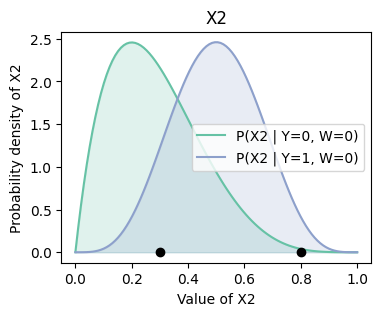

In [57]:
plt.figure(figsize=(4, 3))

vals = np.linspace(0, 1, 100)
px2_1 = stats.beta.pdf(vals, a=2, b=5-3*w)
px2_2 = stats.beta.pdf(vals, a=5, b=5-3*w)

# plt.axhline(0, c="lightgray")
plt.fill_between(vals, 0, px2_1, color=color_list[0], alpha=0.2, zorder=0)
plt.plot(vals, px2_1, color=color_list[0], label="P(X2 | Y=0, W=0)", zorder=1)
plt.fill_between(vals, 0, px2_2, color=color_list[2], alpha=0.2, zorder=0)
plt.plot(vals, px2_2, color=color_list[2], label="P(X2 | Y=1, W=0)", zorder=1)
plt.scatter([x2_1, x2_2], [0, 0], c='black', zorder=2)

plt.legend()
plt.ylabel("Probability density of X2")
plt.xlabel("Value of X2")
plt.title("X2")
plt.savefig(fname="X2_cond.svg", bbox_inches="tight")
plt.show()

In [84]:
num_samples = 100000
threshold = 0.01

x1 = 0.4
x2_1 = 0.3
x2_2 = 0.8
w = 0


def sampling():
    p = np.random.uniform()
    y = stats.binom.rvs(n=1, p=p, size=1)[0]
    x2 = stats.beta.rvs(a=2 + 3 * y, b=5 - 3 * w, size=1)[0]
    return [y, x2]


samples = np.array(Parallel(n_jobs=4)(delayed(sampling)() for _ in range(num_samples)))

y = samples[:, 0]
x2 = samples[:, 1]

idcs_1 = np.less(np.abs(x2 - x2_1), threshold)
idcs_2 = np.less(np.abs(x2 - x2_2), threshold)

py_1 = np.mean(y[idcs_1])
py_2 = np.mean(y[idcs_2])

py_1 = [1 - py_1, py_1]
py_2 = [1 - py_2, py_2]

print(py_1, py_2)

[0.6330459770114942, 0.36695402298850577] [0.12387387387387383, 0.8761261261261262]


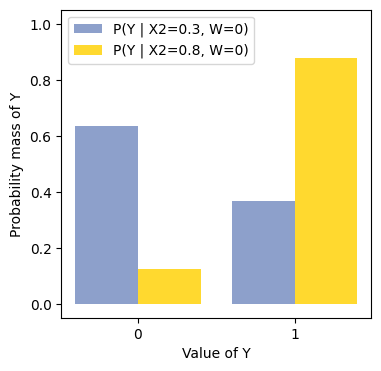

In [91]:
plt.figure(figsize=(4, 4))

vals = np.array([0, 1])
plt.bar(
    vals - 0.2,
    py_1,
    color=color_list[2],
    width=0.4,
    label=f"P(Y | X2={x2_1}, W={w})",
)
plt.bar(
    vals + 0.2,
    py_2,
    color=color_list[5],
    width=0.4,
    label=f"P(Y | X2={x2_2}, W={w})",
)

plt.legend()
plt.xticks(vals)
plt.ylim(-0.05, 1.05)
plt.ylabel("Probability mass of Y")
plt.xlabel("Value of Y")
plt.savefig(fname="X2_pred.pdf", bbox_inches="tight")
plt.show()

In [ ]:
result_df = pd.read_csv("results.csv", index_col=0)

num_envs = 3
fig, axes = plt.subplots(nrows=1, ncols=num_envs, figsize=(8, 4))

model_names = ["naive", "causal", "group", "oracle"]
colour_per_model_name = {
    "naive": "darkorange",
    "causal": "rebeccapurple",
    "group": "forestgreen",
    "oracle": "royalblue",
}
labels_per_model_name = {
    "naive": "Naive Predictor",
    "causal": "Causal Predictor",
    "group": "Group-Instance",
    "oracle": "Oracle",
}

means_per_model_name = {}

for model_name in model_names:
    mean_per_model = result_df[(result_df.model == model_name)].accuracy.mean()
    means_per_model_name[model_name] = 100 * mean_per_model


for env_id in range(3):
    for model_idx, model_name in enumerate(model_names):
        scores = (
            np.array(
                result_df[
                    (result_df.model == model_name) & (result_df.env == env_id)
                ].accuracy
            )
            * 100.0
        )
        x = np.zeros_like(scores) + np.random.uniform(-0.04, 0.04, size=scores.shape)
        axes[env_id].scatter(
            np.zeros_like(scores) + model_idx,
            scores,
            color=colour_per_model_name[model_name],
            alpha=0.2,
            marker="_",
            s=600,
            zorder=1,
        )
        axes[env_id].axhline(
            means_per_model_name[model_name],
            linestyle="--",
            color=colour_per_model_name[model_name],
            alpha=0.5,
            label="",
            zorder=0,
        )

    axes[env_id].set_xlim(-0.5, 3.5)
    axes[env_id].set_ylim(57.0, 93.0)
    if env_id == 0:
        axes[env_id].set_ylabel("Accuracy (%)")
    suffix = ": training" if env_id < 2 else ": testing"
    axes[env_id].set_xticks(
        [
            0.0,
        ],
        [f"Environment {env_id + 1}" + suffix],
        minor=False,
    )
    axes[env_id].xaxis.set_tick_params(labelbottom=False, which="minor")
    axes[env_id].set_xticks(
        np.arange(4), ["Naive", "Causal", "Group", "Oracle"], rotation=-20
    )
    axes[env_id].set_xlabel(f"Environment {env_id + 1}" + suffix)
    axes[env_id].xaxis.set_label_position("top")

y2 = axes[2].twinx()
y2.set_ylim(axes[2].get_ylim())
y2.set_yticks(list(means_per_model_name.values()))
y2.set_yticklabels(["Naive (Mean)", "Causal (Mean)", "Group (Mean)", "Oracle (Mean)"])

# fig.legend(loc="center left", title="Predictor Model", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig("domain_adaptation_results.pdf", bbox_inches="tight")
plt.show()

## Group-instance predictor

In [163]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import scipy.linalg as linalg
import pandas as pd
import multiprocessing as mp

from joblib import Parallel, delayed

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

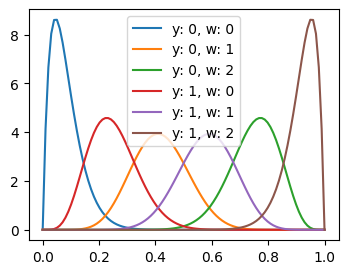

In [164]:
plt.figure(figsize=(4, 3))

vals = np.linspace(0, 1, 100)

y = [0, 1]
w = [0, 1, 2]

for y_ in y:
    for w_ in w:
        p = stats.beta.pdf(vals, a=2 + 4 * y_ + 8 * w_, b=22 - 4 * y_ - 8 * w_)
        plt.plot(vals, p, label=f"y: {y_}, w: {w_}")

plt.legend()
plt.show()

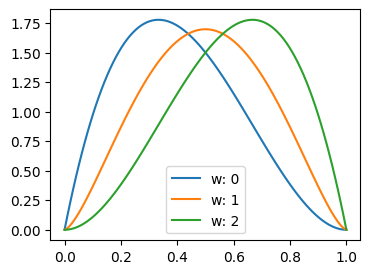

In [188]:
plt.figure(figsize=(4, 3))

vals = np.linspace(0, 1, 100)

y = [0, 1]
w = [0, 1, 2]

for w_ in w:
    p = stats.beta.pdf(vals, a=2 + 0.5 * w_, b=3 - 0.5 * w_)
    plt.plot(vals, p, label=f"w: {w_}")

plt.legend()
plt.show()

In [166]:
class Net(nn.Module):
    def __init__(self, input_dims=[0, 1], output_dim=2, trial_idx=0, batch_size=100):
        super().__init__()
        self.trial_idx = trial_idx
        self.input_dims = input_dims
        self.output_dim = output_dim
        self.batch_size = batch_size

        self.fc = nn.Linear(len(input_dims), 1)

        self.optimiser = optim.SGD(self.parameters(), lr=0.1, momentum=0.0)
        self.loss_func = nn.BCELoss()

    def forward(self, x):
        x = F.sigmoid(self.fc(x))
        return x

    def step(self, train_batch):
        self.optimiser.zero_grad()
        y = self(train_batch[:, self.input_dims])
        train_loss = self.loss_func(y[:, 0], train_batch[:, self.output_dim])
        train_loss.backward()
        self.optimiser.step()
        return train_loss

    def train(self, env_sets, both=False, num_epochs=50, train_size=10000):
        np.random.seed(self.trial_idx)

        env_subsets = []
        for env_set in env_sets:
            idcs = np.arange(env_set.shape[0])
            np.random.shuffle(idcs)
            env_subsets.append(env_set[idcs[:train_size]])
        
        train_sets = env_subsets if both else env_subsets[:-1]
        train_set = np.concatenate(train_sets)

        num_batches = int(np.ceil(train_set.shape[0] / self.batch_size))
        for epoch_idx in range(num_epochs):
            for batch_idx in range(num_batches):
                train_batch = torch.Tensor(
                    train_set[
                        self.batch_size * batch_idx : self.batch_size * (batch_idx + 1)
                    ]
                )
                self.step(train_batch)

        accuracies = []
        for env_idx, env_set in enumerate(env_subsets):
            accuracies.append(self.eval(env_set, epoch_idx, env_idx))

        return accuracies

    def eval(self, test_set, epoch_idx, label):
        num_batches = int(np.ceil(test_set.shape[0] / self.batch_size))
        test_acc = 0
        for batch_idx in range(num_batches):
            test_batch = torch.Tensor(
                test_set[
                    self.batch_size * batch_idx : self.batch_size * (batch_idx + 1)
                ]
            )
            y = self(test_batch[:, self.input_dims])[:, 0]
            test_acc += torch.sum(
                torch.where(
                    test_batch[:, self.output_dim] * y
                    + (1 - test_batch[:, self.output_dim]) * (1.0 - y)
                    > 0.5,
                    1.0,
                    0.0,
                )
            )
        test_acc = test_acc.item() / test_set.shape[0]
        print(f"Epoch {epoch_idx}, {label} Accuracy: {test_acc}")
        return test_acc

In [193]:
num_samples = 100000
num_trials = 40


def spike(x):
    return 1.0 / (1.0 + np.exp(-16.0 * (x - 0.5)))


def sampling(w):
    x1 = stats.beta.rvs(a=2 + 0.5 * w, b=3 - 0.5 * w, size=1)[0]
    y = stats.binom.rvs(n=1, p=x1, size=1)[0]
    x2 = stats.beta.rvs(a=2 + 4 * y + 10 * w, b=26 - 4 * y - 10 * w, size=1)[0]
    # x2 = stats.beta.rvs(a=3, b=3, size=1)[0]
    z = stats.beta.rvs(a=2 + 4 * y + 10, b=26 - 4 * y - 10, size=1)[0]
    return [x1, x2, y, w, z]


def learn(
    env_sets,
    trial_idx=0,
    input_dims=[0, 1],
    output_dim=2,
    model_name="naive",
    both=False,
):
    net = Net(input_dims, output_dim, trial_idx)
    accuracies = net.train(env_sets, both=both)

    df_list = []
    for idx, accuracy in enumerate(accuracies):
        df_list.append(pd.DataFrame(
            {
                "trial_id": [trial_idx],
                "model": [model_name],
                "env": [idx],
                "accuracy": [accuracy],
            }
        ))
    result_df = pd.concat(df_list)
    return result_df


results_df = pd.DataFrame(columns=["trial_id", "model", "env", "accuracy"])

ws = [0, 1, 2]
env_sets = []
for w in ws:
    env_sets.append(np.array(
        Parallel(n_jobs=-2)(delayed(sampling)(w) for _ in range(num_samples))
    ))


args = []
for trial_idx in range(num_trials):
    args = args + [
        {
            "trial_idx": trial_idx,
            "input_dims": [0, 1],
            "output_dim": 2,
            "model_name": "naive",
            "both": False,
        },
        {
            "trial_idx": trial_idx,
            "input_dims": [0],
            "output_dim": 2,
            "model_name": "causal",
            "both": False,
        },
        {
            "trial_idx": trial_idx,
            "input_dims": [0, 4],
            "output_dim": 2,
            "model_name": "group",
            "both": False,
        },
        {
            "trial_idx": trial_idx,
            "input_dims": [0, 1, 3],
            "output_dim": 2,
            "model_name": "oracle",
            "both": True,
        },
    ]

results = Parallel(n_jobs=-2)(delayed(learn)(env_sets, **arg) for arg in args)
# results = [learn(env_sets, **arg) for arg in args]

results_df = pd.concat(results, ignore_index=True)
results_df.to_csv("results.csv")

Epoch 49, 0 Accuracy: 0.6884
Epoch 49, 1 Accuracy: 0.6731
Epoch 49, 0 Accuracy: 0.6238
Epoch 49, 2 Accuracy: 0.6903
Epoch 49, 0 Accuracy: 0.8308
Epoch 49, 1 Accuracy: 0.7784
Epoch 49, 0 Accuracy: 0.6873
Epoch 49, 1 Accuracy: 0.8243
Epoch 49, 2 Accuracy: 0.6093
Epoch 49, 1 Accuracy: 0.6729
Epoch 49, 2 Accuracy: 0.8272
Epoch 49, 2 Accuracy: 0.6881
Epoch 49, 0 Accuracy: 0.6783
Epoch 49, 1 Accuracy: 0.6609
Epoch 49, 0 Accuracy: 0.6819
Epoch 49, 2 Accuracy: 0.6878
Epoch 49, 1 Accuracy: 0.6626
Epoch 49, 2 Accuracy: 0.6939
Epoch 49, 0 Accuracy: 0.8321
Epoch 49, 0 Accuracy: 0.6201
Epoch 49, 1 Accuracy: 0.8221
Epoch 49, 1 Accuracy: 0.7745
Epoch 49, 2 Accuracy: 0.8258
Epoch 49, 2 Accuracy: 0.6092
Epoch 49, 0 Accuracy: 0.8351
Epoch 49, 1 Accuracy: 0.8323
Epoch 49, 0 Accuracy: 0.8366
Epoch 49, 2 Accuracy: 0.8302
Epoch 49, 1 Accuracy: 0.8195
Epoch 49, 0 Accuracy: 0.6224
Epoch 49, 2 Accuracy: 0.8346
Epoch 49, 1 Accuracy: 0.7708
Epoch 49, 2 Accuracy: 0.6163
Epoch 49, 0 Accuracy: 0.6275
Epoch 49, 1 Ac

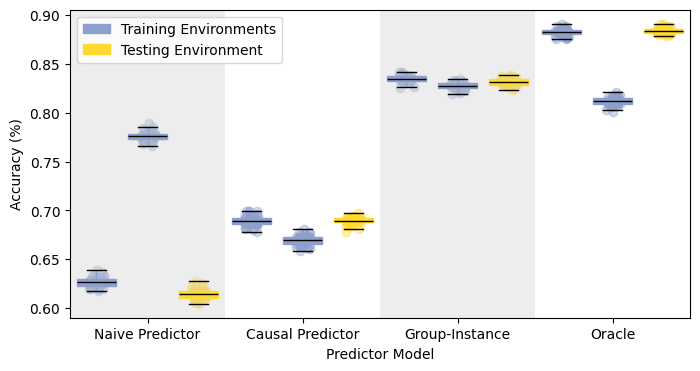

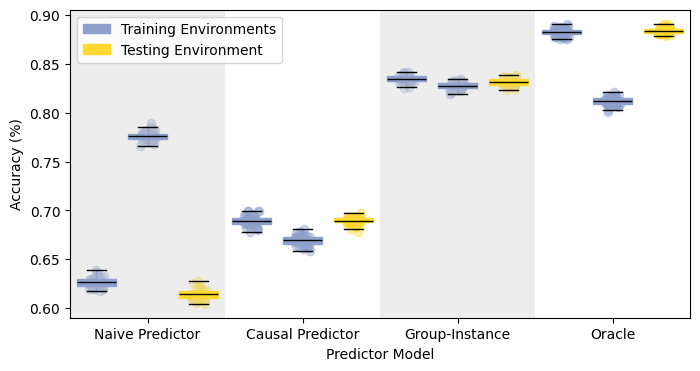

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd


color_list = sns.color_palette("Set2")
plt.figure(figsize=(8, 4))

result_df = pd.read_csv("results.csv", index_col=0)

model_names = ["naive", "causal", "group", "oracle"]
for model_idx, model_name in enumerate(model_names):
    scores = np.array(
        result_df[(result_df.model == model_name) & (result_df.env == 0)].accuracy
    )
    plt.scatter(
        np.zeros_like(scores)
        + model_idx
        - 0.33
        + np.random.uniform(-0.05, 0.05, size=scores.shape),
        scores,
        color=color_list[2],
        alpha=0.4,
    )
    boxplots = plt.boxplot(
        scores,
        positions=[model_idx - 0.33],
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black"),
        label="Training Environments" if model_idx == 0 else None,
        widths=0.25,
        boxprops=dict(facecolor=color_list[2], color=color_list[2]),
        whiskerprops=dict(color=color_list[2]),
    )

    scores = np.array(
        result_df[(result_df.model == model_name) & (result_df.env == 1)].accuracy
    )
    plt.scatter(
        np.zeros_like(scores)
        + model_idx
        + np.random.uniform(-0.05, 0.05, size=scores.shape),
        scores,
        color=color_list[2],
        alpha=0.4,
    )
    boxplots = plt.boxplot(
        scores,
        positions=[model_idx],
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black"),
        widths=0.25,
        boxprops=dict(facecolor=color_list[2], color=color_list[2]),
        whiskerprops=dict(color=color_list[2]),
    )

    scores = np.array(
        result_df[(result_df.model == model_name) & (result_df.env == 2)].accuracy
    )
    plt.scatter(
        np.zeros_like(scores)
        + model_idx
        + 0.33
        + np.random.uniform(-0.05, 0.05, size=scores.shape),
        scores,
        color=color_list[5],
        alpha=0.4,
    )
    boxplots = plt.boxplot(
        scores,
        positions=[model_idx + 0.33],
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black"),
        label="Testing Environment" if model_idx == 0 else None,
        widths=0.25,
        boxprops=dict(facecolor=color_list[5], color=color_list[5]),
        whiskerprops=dict(color=color_list[5]),
    )

    if model_idx % 2 == 0:
        plt.axvspan(model_idx - 0.5, model_idx + 0.5, facecolor="lightgray", alpha=0.4)

plt.xlim(-0.5, 3.5)
plt.xlabel("Predictor Model")
plt.ylabel("Accuracy (%)")
plt.xticks(
    np.arange(4), ["Naive Predictor", "Causal Predictor", "Group-Instance", "Oracle"]
)
plt.legend()
plt.savefig("domain_adaptation_results.pdf")
plt.show()

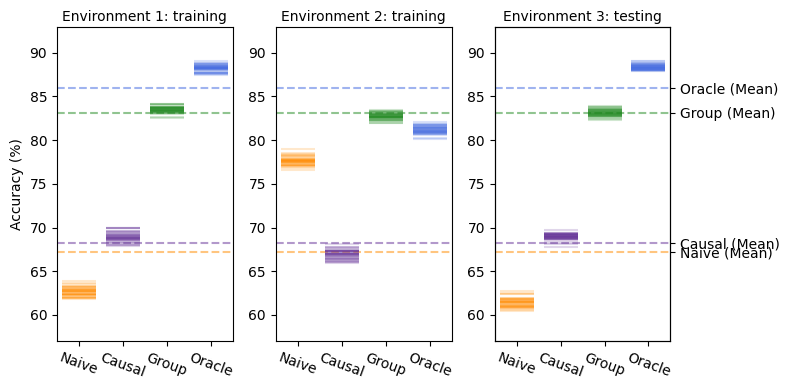

In [75]:
result_df = pd.read_csv("results.csv", index_col=0)

num_envs = 3
fig, axes = plt.subplots(nrows=1, ncols=num_envs, figsize=(8, 4))

model_names = ["naive", "causal", "group", "oracle"]
colour_per_model_name = {
    "naive": "darkorange",
    "causal": "rebeccapurple",
    "group": "forestgreen",
    "oracle": "royalblue",
}
labels_per_model_name = {
    "naive": "Naive Predictor",
    "causal": "Causal Predictor",
    "group": "Group-Instance",
    "oracle": "Oracle",
}

means_per_model_name = {}

for model_name in model_names:
    mean_per_model = result_df[(result_df.model == model_name)].accuracy.mean()
    means_per_model_name[model_name] = 100 * mean_per_model


for env_id in range(3):
    for model_idx, model_name in enumerate(model_names):
        scores = (
            np.array(
                result_df[
                    (result_df.model == model_name) & (result_df.env == env_id)
                ].accuracy
            )
            * 100.0
        )
        x = np.zeros_like(scores) + np.random.uniform(-0.04, 0.04, size=scores.shape)
        axes[env_id].scatter(
            np.zeros_like(scores) + model_idx,
            scores,
            color=colour_per_model_name[model_name],
            alpha=0.2,
            marker="_",
            s=600,
            zorder=1,
        )
        axes[env_id].axhline(
            means_per_model_name[model_name],
            linestyle="--",
            color=colour_per_model_name[model_name],
            alpha=0.5,
            label="",
            zorder=0,
        )

    axes[env_id].set_xlim(-0.5, 3.5)
    axes[env_id].set_ylim(57., 93.0)
    if env_id == 0:
        axes[env_id].set_ylabel("Accuracy (%)")
    suffix = ": training" if env_id < 2 else ": testing"
    axes[env_id].set_xticks(
        [
            0.0,
        ],
        [f"Environment {env_id + 1}" + suffix],
        minor=False,
    )
    axes[env_id].xaxis.set_tick_params(labelbottom=False, which="minor")
    axes[env_id].set_xticks(
        np.arange(4), ["Naive", "Causal", "Group", "Oracle"], rotation=-20
    )
    axes[env_id].set_xlabel(f"Environment {env_id + 1}" + suffix)
    axes[env_id].xaxis.set_label_position("top")

y2 = axes[2].twinx()
y2.set_ylim(axes[2].get_ylim())
y2.set_yticks(list(means_per_model_name.values()))
y2.set_yticklabels(["Naive (Mean)", "Causal (Mean)", "Group (Mean)", "Oracle (Mean)"])

# fig.legend(loc="center left", title="Predictor Model", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig("domain_adaptation_results.pdf", bbox_inches='tight')
plt.show()

In [19]:
import numpy as np

x = (8 * np.log(10)) - (16 * 16 * np.log(2))
print(100 * np.exp(x))

8.636168555094571e-68
